Using device: cuda
Starting Adam Warm-up...
Iter      0 | PDE: 5.729e-05 | IC: 8.849e-01 | Path: 1.466e-22
Iter    500 | PDE: 6.792e-03 | IC: 8.756e-02 | Path: 2.596e-15
Iter   1000 | PDE: 6.683e-03 | IC: 6.749e-02 | Path: 2.659e-15
Iter   1500 | PDE: 1.544e-02 | IC: 5.132e-02 | Path: 2.535e-15
Switching to L-BFGS...
Iter   2000 | PDE: 8.315e-03 | IC: 3.656e-02 | Path: 2.516e-15
Iter   2500 | PDE: 5.557e-03 | IC: 1.042e-02 | Path: 2.611e-15
Iter   3000 | PDE: 3.833e-03 | IC: 4.687e-03 | Path: 2.769e-15
Iter   3500 | PDE: 3.440e-03 | IC: 1.859e-03 | Path: 2.310e-15
Iter   4000 | PDE: 2.543e-03 | IC: 7.871e-04 | Path: 2.211e-15
Iter   4500 | PDE: 1.539e-03 | IC: 3.001e-04 | Path: 1.986e-15
Iter   5000 | PDE: 1.058e-03 | IC: 2.097e-04 | Path: 2.193e-15
Iter   5500 | PDE: 6.156e-04 | IC: 3.595e-05 | Path: 2.019e-15
Iter   6000 | PDE: 4.208e-04 | IC: 2.837e-05 | Path: 1.947e-15
Iter   6500 | PDE: 3.071e-04 | IC: 2.481e-05 | Path: 2.527e-15
Iter   7000 | PDE: 2.462e-04 | IC: 1.587e-05 | Path

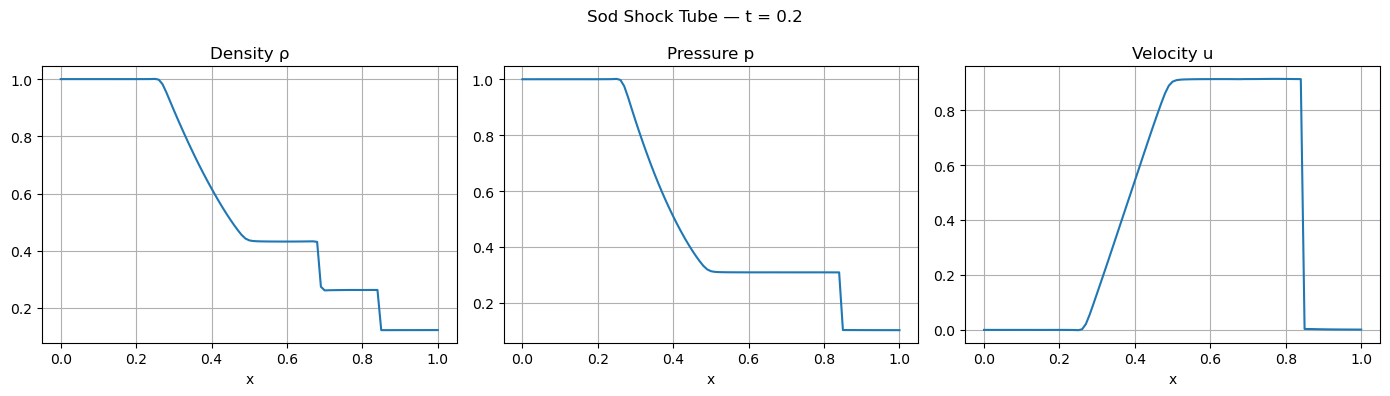

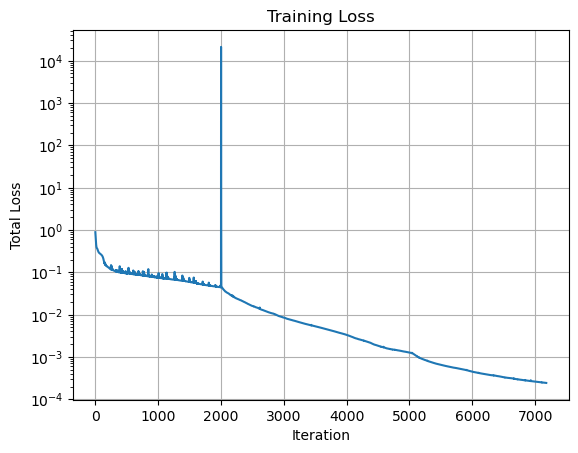

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import time
import os
import matplotlib.pyplot as plt

# Seeds
torch.manual_seed(12)
np.random.seed(12)

# Domain
x_min = 0
x_max = 1
t_max = 0.2
nx = 101
nt = 101
ct = 1
x0=0.5
er_c1 = 1e-3

# ── Helpers ───────────────────────────────────────────────────────────────────

def gradients(outputs, inputs):
    """Compute gradients via autograd."""
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True
    )

def to_numpy(input):
    if isinstance(input, torch.Tensor):
        return input.detach().cpu().numpy()
    elif isinstance(input, np.ndarray):
        return input
    else:
        raise TypeError(f'Expected torch.Tensor or np.ndarray, got {type(input)}')

# ── Initial Conditions ────────────────────────────────────────────────────────

def IC(x):
    """Sod shock-tube initial conditions."""
    N = len(x)
    rho_init = np.zeros(N)
    u_init   = np.zeros(N)
    p_init   = np.zeros(N)

    for i in range(N):
        if x[i] <= x0:
            rho_init[i] = 1.0
            p_init[i]   = 1.0
        else:
            rho_init[i] = 0.125
            p_init[i]   = 0.1

    return rho_init, u_init, p_init

# ── Activation Function ───────────────────────────────────────────────────────

class ParamTanh(nn.Module):
    """Adaptive tanh with learnable (clamped) slope parameter."""
    def __init__(self, alpha=0.9):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(alpha))

    def forward(self, x):
        alpha = torch.clamp(self.alpha, min=0.1, max=10.0)
        return torch.tanh(alpha * x)

# ── Network ───────────────────────────────────────────────────────────────────

class DNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential()

       
        tn = 32

        self.net.add_module('Linear_layer_1', nn.Linear(2, tn))
        self.net.add_module('Tanh_layer_1',   nn.Tanh())

        for num in range(2, 5):
            self.net.add_module(f'Linear_layer_{num}', nn.Linear(tn, tn))
            self.net.add_module(f'Tanh_layer_{num}',   ParamTanh(alpha=0.9))

        
        self.net.add_module('Linear_layer_final', nn.Linear(tn, 3))

    def forward(self, x):
        return self.net(x)

    # ── PDE Loss ──────────────────────────────────────────────────────────────

    def loss_pde(self, x):
        y = self.net(x)
        rho, p, u = y[:, 0:1], y[:, 1:2], y[:, 2:3]

       
        rho = torch.clamp(rho, min=1e-4)
        p   = torch.clamp(p,   min=1e-4)

        gamma = 1.4

        drho_g   = gradients(rho, x)[0]
        rho_t, rho_x = drho_g[:, :1], drho_g[:, 1:]

        du_g     = gradients(u, x)[0]
        u_t,   u_x   = du_g[:, :1],   du_g[:, 1:]

        dp_g     = gradients(p, x)[0]
        p_t,   p_x   = dp_g[:, :1],   dp_g[:, 1:]

        # Second derivatives
        drho_gg  = gradients(rho_x, x)[0]
        rho_xx   = drho_gg[:, 1:]

        du_gg    = gradients(u_x, x)[0]
        u_xx     = du_gg[:, 1:]

        dp_gg    = gradients(p_x, x)[0]
        p_xx     = dp_gg[:, 1:]

        # Upwind-style stabilisation (compression regions)
        d = 0.15 * (torch.abs(u_x) - u_x) + 1.0
        # d = 0.15 * (abs(u_x) - u_x) + 0.1 * (abs(p_x) / (p + 1e-6)) + 1.0  
        # Non-conservative Euler equations (viscosity disabled — nu=0)
        continuity_eq = (rho_t + u * rho_x + rho * u_x) / d
        momentum_eq   = (u_t + u * u_x + (1.0 / rho) * p_x) / d
        energy_eq     = (p_t + u * p_x + gamma * p * u_x) / d

        f = (continuity_eq**2).mean() \
          + (momentum_eq**2).mean()   \
          + (energy_eq**2).mean()

        return f

    # ── IC Loss ───────────────────────────────────────────────────────────────

    def loss_ic(self, x_ic, rho_ic, u_ic, p_ic):
        y_ic = self.net(x_ic)
        rho_ic_nn = y_ic[:, 0]
        p_ic_nn   = y_ic[:, 1]
        u_ic_nn   = y_ic[:, 2]

        loss_ics = ((rho_ic_nn - rho_ic)**2).mean() \
                 + ((u_ic_nn   - u_ic  )**2).mean() \
                 + ((p_ic_nn   - p_ic  )**2).mean()

        return loss_ics

    # ── Path-Conservative Loss ────────────────────────────────────────────────

    def loss_path(self, x_collocation, eps=1e-4, gamma=1.4):


        x_L = x_collocation.clone()
        x_R = x_collocation.clone()
        x_L[:, 1] = torch.clamp(x_L[:, 1] - eps, min=x_min, max=x_max)  
        x_R[:, 1] = torch.clamp(x_R[:, 1] + eps, min=x_min, max=x_max)

        y_L = self.net(x_L)
        y_R = self.net(x_R)

        def to_cons(y):
            rho = torch.clamp(y[:, 0:1], min=1e-4)  
            p   = torch.clamp(y[:, 1:2], min=1e-4) 
            u   = y[:, 2:3]
            m   = rho * u
            E   = p / (gamma - 1) + 0.5 * rho * u**2
            return torch.cat([rho, m, E], dim=1)

        U_L = to_cons(y_L)
        U_R = to_cons(y_R)
        delta_U = U_R - U_L

        # 3-point Gauss-Legendre quadrature on [0, 1]
        nodes   = torch.tensor([0.1127, 0.5, 0.8873], device=x_collocation.device)
        weights = torch.tensor([0.2778, 0.4444, 0.2778], device=x_collocation.device)

        integral_term = torch.zeros_like(U_L)

        for i in range(len(nodes)):
            U_s = U_L + nodes[i] * delta_U

 
            rho_s = torch.clamp(U_s[:, 0], min=1e-4)
            m_s   = U_s[:, 1]
            E_s   = U_s[:, 2]

            u_s = m_s / rho_s
            p_s = (gamma - 1) * (E_s - 0.5 * rho_s * u_s**2)
            H_s = (E_s + p_s) / rho_s

            # Jacobian-vector product A(U_s) * delta_U
            jvp_0 = delta_U[:, 1]
            jvp_1 = (0.5*(gamma-3)*u_s**2)*delta_U[:, 0] \
                  + ((3-gamma)*u_s)        *delta_U[:, 1] \
                  + (gamma-1)              *delta_U[:, 2]
            jvp_2 = (u_s*(0.5*(gamma-1)*u_s**2 - H_s))*delta_U[:, 0] \
                  + (H_s - (gamma-1)*u_s**2)            *delta_U[:, 1] \
                  + (gamma*u_s)                          *delta_U[:, 2]

            integral_term += weights[i] * torch.stack([jvp_0, jvp_1, jvp_2], dim=1)

        def get_F(U):
            rho = U[:, 0:1]
            m   = U[:, 1:2]
            E   = U[:, 2:3]
            u   = m / rho
            p   = (gamma - 1) * (E - 0.5 * rho * u**2)
            return torch.cat([m, m*u + p, u*(E+p)], dim=1)

        flux_jump = get_F(U_R) - get_F(U_L)
        return torch.mean(torch.sum((integral_term - flux_jump)**2, dim=1))


# ── Device ────────────────────────────────────────────────────────────────────

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# ── Collocation Points ────────────────────────────────────────────────────────

x_arr = np.linspace(x_min, x_max, nx)
t_arr = np.linspace(0, t_max, nt)
t_grid, x_grid = np.meshgrid(t_arr, x_arr)

T = t_grid.flatten()[:, None]
X = x_grid.flatten()[:, None]

x_int_train = np.hstack((T, X))           # interior collocation: (t, x)

# IC points (t=0)
x_ic    = x_grid[:, 0][:, None]
t_ic    = t_grid[:, 0][:, None]
x_ic_train = np.hstack((t_ic, x_ic))

rho_ic_train, u_ic_train, p_ic_train = IC(x_ic.flatten())

# Convert to tensors
x_ic_train   = torch.tensor(x_ic_train,   dtype=torch.float32).to(device)
x_int_train  = torch.tensor(x_int_train,  requires_grad=True, dtype=torch.float32).to(device)
rho_ic_train = torch.tensor(rho_ic_train, dtype=torch.float32).to(device)
u_ic_train   = torch.tensor(u_ic_train,   dtype=torch.float32).to(device)
p_ic_train   = torch.tensor(p_ic_train,   dtype=torch.float32).to(device)

# ── Model & Optimiser ─────────────────────────────────────────────────────────

model = DNN().to(device)
# Replace the training block with this:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = []
iter_count   = [0]

def closure():
    optimizer.zero_grad()

    loss_pde  = model.loss_pde(x_int_train)
    loss_ic   = model.loss_ic(x_ic_train, rho_ic_train, u_ic_train, p_ic_train)
    loss_path = model.loss_path(x_int_train)

    # Diagnostic print every 500 iters
    if iter_count[0] % 500 == 0:
        print(f"Iter {iter_count[0]:6d} | "
              f"PDE: {loss_pde.item():.3e} | "
              f"IC: {loss_ic.item():.3e} | "
              f"Path: {loss_path.item():.3e}")

    iter_count[0] += 1

    loss = loss_pde + 1.0 * loss_ic + 1.0 * loss_path   # increased path weight

    if torch.isnan(loss):
        print("NaN detected — skipping backward.")
        return torch.tensor(0.0, requires_grad=True, device=device)

    loss.backward()
    loss_history.append(loss.item())
    return loss

# ── Updated Training Block ───────────────────────────────────────────────────

print("Starting Adam Warm-up...")
optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
for i in range(2000):
    optimizer.zero_grad()
    

    loss = closure() 

    optimizer_adam.step()

print("Switching to L-BFGS...")
# L-BFGS handles the closure calls internally

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=5000,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    line_search_fn='strong_wolfe'
)

# ── Training ──────────────────────────────────────────────────────────────────


start = time.time()
optimizer.step(closure)
print(f"Training finished in {time.time()-start:.1f}s")

# ── Inference & Plots ─────────────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    y_pred = model(x_int_train.detach()).cpu().numpy()

rho_pred = y_pred[:, 0].reshape(nx, nt)
p_pred   = y_pred[:, 1].reshape(nx, nt)
u_pred   = y_pred[:, 2].reshape(nx, nt)

x_plot = np.linspace(x_min, x_max, nx)
t_idx  = -1   # final time slice

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Density ρ', 'Pressure p', 'Velocity u']
data   = [rho_pred, p_pred, u_pred]

for ax, title, d in zip(axes, titles, data):
    ax.plot(x_plot, d[:, t_idx])
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.grid(True)

plt.suptitle(f'Sod Shock Tube — t = {t_max}')
plt.tight_layout()
plt.show()

# Loss curve
if loss_history:
    plt.figure()
    plt.semilogy(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Total Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.show()

In [4]:
data=np.zeros((nx, 4))
data[:,0] = x_plot.flatten()  # FIX: ensure x_plot is 1D
data[:,1] = p_pred[:, -1].flatten()
data[:,2] = rho_pred[:, -1].flatten()
data[:,3] = u_pred[:, -1].flatten()
np.savetxt('sod_pinn_noncons_path_15.dat', data)

In [5]:
# 1. Prepare the data (x, t, rho, u, p)
model.eval()
with torch.no_grad():
    # Extract coordinates (t, x)
    coords = x_int_train.detach().cpu().numpy()
    t_vals = coords[:, 0:1]
    x_vals = coords[:, 1:2]
    
    # Get predictions (rho, p, u)
    preds = model(x_int_train).detach().cpu().numpy()
    rho_p = preds[:, 0:1]
    p_p   = preds[:, 1:2]
    u_p   = preds[:, 2:3]

# 2. Stack as [x, t, rho, u, p]
# Note: I'm putting u before p to match your requested order (x, t, rho, u, p)
final_data = np.hstack((x_vals, t_vals, rho_p, u_p, p_p))

# 3. Sort the data (by time, then by x) for a clean structure
# This ensures that the .dat file isn't a jumbled mess of points
indices = np.lexsort((final_data[:, 0], final_data[:, 1]))
final_data = final_data[indices]

# 4. Save to .dat file
header = "x          t          rho        u          p"
np.savetxt("sod_results.dat", final_data, header=header, fmt="%.8e", comments='')

print("✅ Results saved to sod_results.dat")

✅ Results saved to sod_results.dat
